# Target Trial Emulation version 2 (TTE-v2)

This is TTE but with clustering applied.

# Libraries/modules used

The module `TrialEmulation_python` is the Python code we converted from the TrialEmulation package of R.

In [1]:
import TrialEmulation_python as ttepy
import statsmodels.api as sm
import os
import tempfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# The data

In [2]:
data = pd.read_csv("data_censored.csv")
display(data)

,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0
2,1,2,1,0,-0.481762,0,0.734203,38,0.250000,0,0,0
3,1,3,1,0,0.007872,0,0.734203,39,0.333333,0,0,0
4,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
720,99,3,0,0,-0.747906,1,0.575268,68,2.750000,0,0,0
721,99,4,0,0,-0.790056,1,0.575268,69,2.833333,0,0,0
722,99,5,1,1,0.387429,1,0.575268,70,2.916667,0,0,0
723,99,6,1,1,-0.033762,1,0.575268,71,3.000000,0,0,0


# Insights on the observational data before applying TTE with clustering

## Correlation of x1, x2, x3, and x4 with age

#### Mean ± Confidence Interval Plot (Summarized trends)

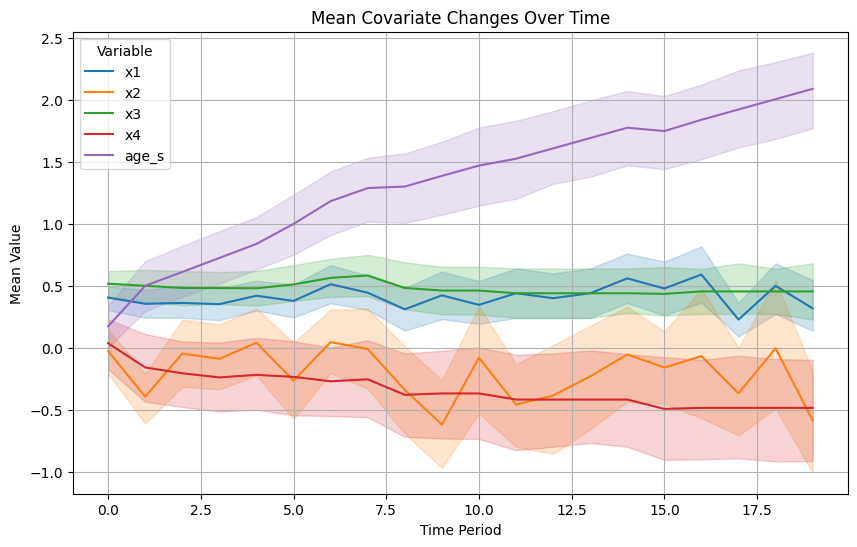

In [3]:
plt.figure(figsize=(10, 6))

# Plot mean and confidence interval for each variable
for variable in ['x1', 'x2', 'x3', 'x4', 'age_s']:
    sns.lineplot(data=data, x='period', y=variable, estimator='mean', errorbar=('ci', 95), label=variable)

plt.xlabel("Time Period")
plt.ylabel("Mean Value")
plt.title("Mean Covariate Changes Over Time")
plt.legend(title="Variable")
plt.grid(True)
plt.show()


#### Pearson's r

In [4]:
# Compute Pearson correlation between age and each covariate
correlations = data[['age_s', 'x1', 'x2', 'x3', 'x4']].corr()
print(correlations['age_s'])

age_s    1.000000
x1       0.040720
x2       0.002637
x3      -0.135130
x4      -0.232485
Name: age_s, dtype: float64


#### Linear Regression (Check Dependency on Age)

In [5]:
# Fit regression models
for var in ['x1', 'x2', 'x3', 'x4']:
    X = sm.add_constant(data['age_s'])  # Add intercept
    y = data[var]
    model = sm.OLS(y, X).fit()
    print(f"\nRegression results for {var} ~ age_s:")
    print(model.summary())


Regression results for x1 ~ age_s:
                            OLS Regression Results                            
Dep. Variable:                     x1   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.201
Date:                Mon, 10 Mar 2025   Prob (F-statistic):              0.274
Time:                        00:07:44   Log-Likelihood:                -512.42
No. Observations:                 725   AIC:                             1029.
Df Residuals:                     723   BIC:                             1038.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0

### Interpretation

x1 and x2 are nearly uncorrelated with age_s. Changes in age do not meaningfully affect these covariates. x3 has a slight negative trend with age, but it's weak. x4 shows the strongest (negative) correlation with age, suggesting that as patients get older, x4 tends to decrease. Although x4 has the strongest negative effect among the covariates, it is still weak in practical terms. The statistical analyses performed above show that the covariates x1, x2, x3, and x4 remain stable across time periods.

## Checking the data distribution & shape

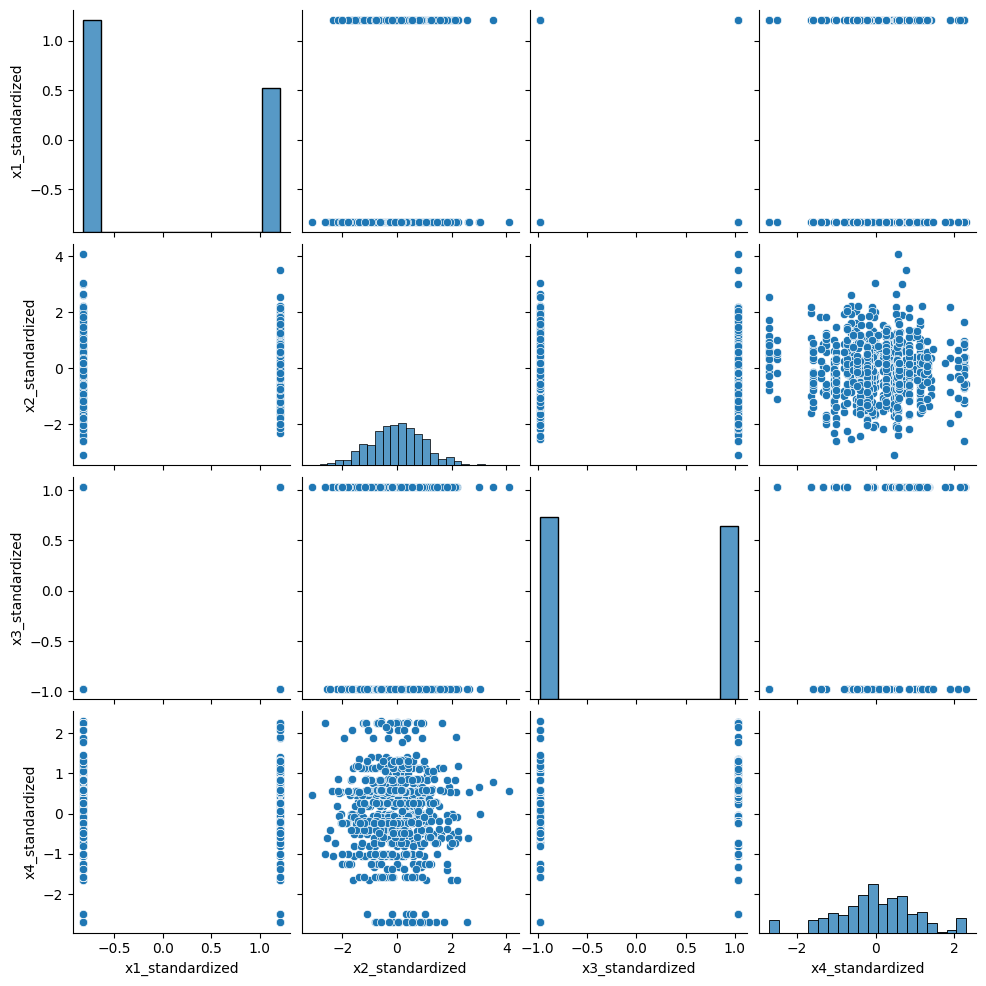

In [6]:
# Load your original dataset (assuming df is your DataFrame)
df = data.copy()  # Make a copy to preserve the original

# Select only the features to standardize
features = ['x1', 'x2', 'x3', 'x4']
features_s = ['x1_standardized', 'x2_standardized', 'x3_standardized', 'x4_standardized']
# continuous_features = ['x2', 'x4']

# Standardize the selected features
scaler = StandardScaler()
df_standardized = df.copy()  # Preserve the full structure
df_standardized[features_s] = scaler.fit_transform(df[features])

sns.pairplot(df_standardized[features_s])
plt.show()

#display(df_standardized[features_s])

**Interpretation for the above diagram**

Data for covariates x2 and x4 are approximately normally distributed. Data for covariates x1 and x3 are bimodal and likely represent categorical data. The diagrams not in the main diagonal of the grid, except for the x1-x3 diagram, have naturally forming clusters. This suggests that clustering will work well for these covariates in the aformentioned diagrams.



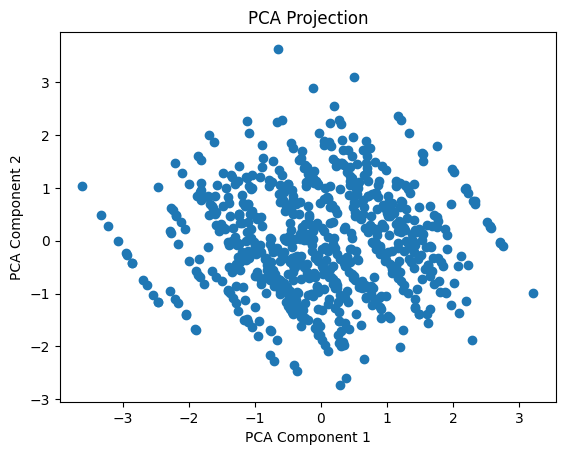

In [7]:
# PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_standardized[features_s])

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection")
plt.show()


**Interpretation for the above diagram**

This PCA projection shows a fairly continuous distribution of data points with no distinct clusters, suggesting that the first two principal components do not separate the data into well-defined groups. The diamond-like shape indicates some correlation among the features, where variance is spread along diagonal axes. The density of points in the center suggests that most observations share similar characteristics, with fewer extreme values at the edges. 

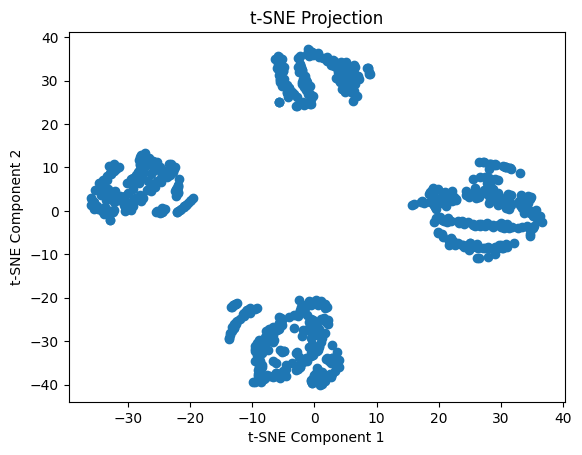

In [8]:
# t-SNE for better non-linear structure visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_standardized[features_s])

plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Projection")
plt.show()

**Interpretation for the above diagram**

This t-SNE projection suggests that the data naturally forms distinct clusters in a lower-dimensional space. Unlike PCA, which showed a more continuous spread, t-SNE has uncovered well-separated groups, indicating that the features contain structure that may correspond to meaningful patterns or categories. The presence of multiple, compact clusters suggests that the dataset likely has underlying groupings, potentially corresponding to different classes or categories. If these clusters align with known labels, it confirms their significance; otherwise, further investigation (e.g., clustering algorithms) could reveal hidden patterns in the data.

# Implementation 

The TrialEmulation package of R was used for converting relevant R code for the classes, functions, and methods used in TTE to Python.

## 1. Perform clustering on the observational data

Based on the generated insights of the observational data before applying TTE with clustering, DBSCAN clustering algorithm is ideal because the **t-SNE projection** clearly showed distinct, non-spherical clusters. Unlike K-Means, which assumes circular clusters, DBSCAN can detect arbitrary-shaped clusters, making it a better fit for the observational data. DBSCAN also automatically determines the number of clusters based on density, which is useful given the natural separations observed in the t-SNE plot. The varying densities of the data are another reason why DBSCAN is ideal because it can adapt to such variations. Lastly, the PCA projection suggests that the data is spread out with some potential noise points. DBSCAN naturally labels noise as -1, making it effective for handling outliers without forcing them into clusters.

In [9]:
# Set parameters (adjust as needed)
eps = 2  # Maximum distance between two points to be considered neighbors
min_samples = 5  # Minimum points needed to form a dense region

# Fit DBSCAN on your standardized features
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(df_standardized[features_s])  # Replace 'features' with actual column names

# Check unique cluster labels (-1 represents noise points)

print(f"Unique clusters: {np.unique(labels)}")

df['cluster'] = labels
display(df)


Unique clusters: [0 1 2 3]


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1,0
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0,0
2,1,2,1,0,-0.481762,0,0.734203,38,0.250000,0,0,0,1
3,1,3,1,0,0.007872,0,0.734203,39,0.333333,0,0,0,1
4,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,99,3,0,0,-0.747906,1,0.575268,68,2.750000,0,0,0,2
721,99,4,0,0,-0.790056,1,0.575268,69,2.833333,0,0,0,2
722,99,5,1,1,0.387429,1,0.575268,70,2.916667,0,0,0,3
723,99,6,1,1,-0.033762,1,0.575268,71,3.000000,0,0,0,3


### 1.1 Store the data into their appropriate cluster dataframe

In [10]:
df_clusters = {}  # Dictionary to store DataFrames

for cluster_label in np.unique(labels):  # Iterate over unique cluster labels
    df_clusters[f'Cluster_{cluster_label}'] = df[df['cluster'] == cluster_label]

    # Accessing a specific cluster DataFrame
    display(df_clusters[f'Cluster_{cluster_label}'])



,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1,0
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0,0
4,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0,0
6,2,0,0,1,-0.802142,0,-0.990794,26,-0.750000,0,0,1,0
7,2,1,1,1,-0.983030,0,-0.990794,27,-0.666667,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,95,19,0,1,0.428118,0,-0.001647,56,1.750000,0,0,0,0
702,98,0,1,1,1.392339,0,0.317418,64,2.416667,0,0,1,0
703,98,1,1,1,-0.934798,0,0.317418,65,2.500000,0,0,0,0
706,98,4,0,1,1.045454,0,0.317418,68,2.750000,0,0,0,0


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster
2,1,2,1,0,-0.481762,0,0.734203,38,0.250000,0,0,0,1
3,1,3,1,0,0.007872,0,0.734203,39,0.333333,0,0,0,1
5,1,5,1,0,-0.057482,0,0.734203,41,0.500000,0,1,0,1
8,2,2,1,0,0.399388,0,-0.990794,28,-0.583333,0,0,0,1
9,2,3,0,0,1.835085,0,-0.990794,29,-0.500000,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,98,10,1,0,0.874095,0,0.317418,74,3.250000,0,0,0,1
713,98,11,1,0,0.019309,0,0.317418,75,3.333333,0,0,0,1
714,98,12,0,0,-1.252629,0,0.317418,76,3.416667,0,0,0,1
715,98,13,0,0,-0.006988,0,0.317418,77,3.500000,0,0,0,1


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster
11,3,0,1,0,0.571029,1,0.391966,48,1.083333,0,0,1,2
13,3,2,1,0,1.721724,1,0.391966,50,1.250000,0,0,0,2
14,3,3,1,0,0.755487,1,0.391966,51,1.333333,0,0,0,2
15,3,4,0,0,-0.312559,1,0.391966,52,1.416667,0,0,0,2
18,3,7,1,0,2.831169,1,0.391966,55,1.666667,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,99,1,1,0,-1.106481,1,0.575268,66,2.583333,0,0,0,2
719,99,2,0,0,1.650478,1,0.575268,67,2.666667,0,0,0,2
720,99,3,0,0,-0.747906,1,0.575268,68,2.750000,0,0,0,2
721,99,4,0,0,-0.790056,1,0.575268,69,2.833333,0,0,0,2


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster
12,3,1,1,1,-0.858627,1,0.391966,49,1.166667,0,0,0,3
16,3,5,0,1,-0.446701,1,0.391966,53,1.500000,0,0,0,3
17,3,6,0,1,-0.030820,1,0.391966,54,1.583333,0,0,0,3
20,4,1,0,1,0.693649,1,-1.613258,30,-0.416667,0,0,1,3
31,6,3,1,1,-1.601660,1,0.003098,37,0.166667,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
698,96,17,0,1,-0.962519,1,-1.293043,64,2.416667,0,0,0,3
701,97,0,0,1,0.621108,1,0.830741,36,0.083333,0,1,1,3
717,99,0,1,1,-0.346378,1,0.575268,65,2.500000,0,0,1,3
722,99,5,1,1,0.387429,1,0.575268,70,2.916667,0,0,0,3


## 2. Setup

A sequence of target trials analysis starts by specifying which estimand will be used:

In [11]:
# Initialize trial sequences for each cluster
trial_pp = {f'Cluster_{cluster_label}': ttepy.trial_sequence(estimand="PP") 
            for cluster_label in np.unique(labels)}

trial_itt = {f'Cluster_{cluster_label}': ttepy.trial_sequence(estimand="ITT")  
             for cluster_label in np.unique(labels)}

Additionally it is useful to create a directory to save files for later inspection.

In [12]:
# Create base directories for all clusters
base_trial_pp_clusters_dir = os.path.join(os.getcwd(), "trial_pp_clusters")
base_trial_itt__clusters_dir = os.path.join(os.getcwd(), "trial_itt_clusters")

# Initialize a dictionary to store paths for each cluster
trial_pp_clusters_dirs = {}
trial_itt_clusters_dirs = {}

for cluster_label in np.unique(labels):  
    # Create directories specific to each cluster
    trial_pp_clusters_dirs[f'Cluster_{cluster_label}'] = os.path.join(base_trial_pp_clusters_dir, f"cluster_{cluster_label}")
    trial_itt_clusters_dirs[f'Cluster_{cluster_label}'] = os.path.join(base_trial_itt__clusters_dir, f"cluster_{cluster_label}")

    os.makedirs(trial_pp_clusters_dirs[f'Cluster_{cluster_label}'], exist_ok=True)
    os.makedirs(trial_itt_clusters_dirs[f'Cluster_{cluster_label}'], exist_ok=True)

## 2. Data preparation

In [13]:
for cluster_label in np.unique(labels):  
    data_cluster = df_clusters[f'Cluster_{cluster_label}']  # Extract cluster-specific data

    print(type(data_cluster))

    trial_pp[f'Cluster_{cluster_label}'].set_data(
        data=data_cluster,
        ID="id",
        period="period",
        treatment="treatment",
        outcome="outcome",
        eligible="eligible"
    )

    trial_itt[f'Cluster_{cluster_label}'].set_data(
        data=data_cluster,
        ID="id",
        period="period",
        treatment="treatment",
        outcome="outcome",
        eligible="eligible"
    )

    trial_itt[f'Cluster_{cluster_label}'].show()
    


<class 'pandas.core.frame.DataFrame'>
Trial Sequence Object
Estimand: ITT

Data:
 - N: 157 observations from 31 patients


/home/ian/school/data_analytics/Assignments/clustering_assignment_1/TrialEmulation_python.py:195: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sw_data.loc[switch_mask & (treatment == 1), ["started1", "eligible1_sw"]] = 1
/home/ian/school/data_analytics/Assignments/clustering_assignment_1/TrialEmulation_python.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sw_data.loc[switch_mask & (treatment == 0), ["started0", "eligible0_sw"]] = 1


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster,time_on_regime
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1,0,0.0
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0,0,1.0
2,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0,0,4.0
3,2,0,0,1,-0.802142,0,-0.990794,26,-0.750000,0,0,1,0,0.0
4,2,1,1,1,-0.983030,0,-0.990794,27,-0.666667,0,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,95,19,0,1,0.428118,0,-0.001647,56,1.750000,0,0,0,0,13.0
153,98,0,1,1,1.392339,0,0.317418,64,2.416667,0,0,1,0,0.0
154,98,1,1,1,-0.934798,0,0.317418,65,2.500000,0,0,0,0,1.0
155,98,4,0,1,1.045454,0,0.317418,68,2.750000,0,0,0,0,4.0



IPW for informative censoring:
 - No weight model specified

Sequence of Trials Data:
- Use set_expansion_options() and expand_trials() to construct the sequence of trials dataset.

Outcome model:
 - Outcome model not specified. Use set_outcome_model()

<class 'pandas.core.frame.DataFrame'>
Trial Sequence Object
Estimand: ITT

Data:
 - N: 215 observations from 42 patients


/home/ian/school/data_analytics/Assignments/clustering_assignment_1/TrialEmulation_python.py:195: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sw_data.loc[switch_mask & (treatment == 1), ["started1", "eligible1_sw"]] = 1
/home/ian/school/data_analytics/Assignments/clustering_assignment_1/TrialEmulation_python.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sw_data.loc[switch_mask & (treatment == 0), ["started0", "eligible0_sw"]] = 1


...


IPW for informative censoring:
 - No weight model specified

Sequence of Trials Data:
- Use set_expansion_options() and expand_trials() to construct the sequence of trials dataset.

Outcome model:
 - Outcome model not specified. Use set_outcome_model()

<class 'pandas.core.frame.DataFrame'>


/home/ian/school/data_analytics/Assignments/clustering_assignment_1/TrialEmulation_python.py:195: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sw_data.loc[switch_mask & (treatment == 1), ["started1", "eligible1_sw"]] = 1
/home/ian/school/data_analytics/Assignments/clustering_assignment_1/TrialEmulation_python.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  sw_data.loc[switch_mask & (treatment == 0), ["started0", "eligible0_sw"]] = 1


Trial Sequence Object
Estimand: ITT

Data:
 - N: 137 observations from 36 patients


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster,time_on_regime
0,3,1,1,1,-0.858627,1,0.391966,49,1.166667,0,0,0,3,0.0
1,3,5,0,1,-0.446701,1,0.391966,53,1.500000,0,0,0,3,4.0
2,3,6,0,1,-0.030820,1,0.391966,54,1.583333,0,0,0,3,1.0
3,4,1,0,1,0.693649,1,-1.613258,30,-0.416667,0,0,1,3,0.0
4,6,3,1,1,-1.601660,1,0.003098,37,0.166667,0,0,0,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,96,17,0,1,-0.962519,1,-1.293043,64,2.416667,0,0,0,3,6.0
133,97,0,0,1,0.621108,1,0.830741,36,0.083333,0,1,1,3,0.0
134,99,0,1,1,-0.346378,1,0.575268,65,2.500000,0,0,1,3,0.0
135,99,5,1,1,0.387429,1,0.575268,70,2.916667,0,0,0,3,5.0



IPW for informative censoring:
 - No weight model specified

Sequence of Trials Data:
- Use set_expansion_options() and expand_trials() to construct the sequence of trials dataset.

Outcome model:
 - Outcome model not specified. Use set_outcome_model()



## 3. Weight Models and Censoring

### 3.1 Censoring due to treatment switching

We specify model formulas to be used for calculating the probability of receiving treatment in the current period. Separate models are fitted for patients who had treatment = 1 and those who had treatment = 0 in the previous period. Stabilized weights are used by fitting numerator and denominator models.

There are optional arguments to specify columns which can include/exclude observations from the treatment models. These are used in case it is not possible for a patient to deviate from a certain treatment assignment in that period.

In [14]:
for cluster_label in np.unique(labels):  
    print(f"Cluster {cluster_label}")

    trial_pp[f'Cluster_{cluster_label}'].set_switch_weight_model(
        numerator="~age",
        denominator="~age + x1 + x3",
        model_fitter=ttepy.stats_glm_logit(save_path=os.path.join(trial_pp_clusters_dirs[f'Cluster_{cluster_label}'], "switch_models"))
    )

    trial_pp[f'Cluster_{cluster_label}'].switch_weights.show()
    print("\n")
        
# # Call set_switch_weight_model
# trial_pp.set_switch_weight_model(
#     numerator="~age",
#     denominator="~age + x1 + x3",
#     model_fitter=ttepy.stats_glm_logit(save_path=os.path.join(trial_pp_dir, "switch_models"))
# )

# # Access and inspect switch_weights (equivalent to trial_pp@switch_weights)
# trial_pp.switch_weights.show()

Cluster 0
 - Numerator formula: treatment ~ age
 - Denominator formula: treatment ~ age + x1 + x3
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 1
 - Numerator formula: treatment ~ age
 - Denominator formula: treatment ~ age + x1 + x3
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 2
 - Numerator formula: treatment ~ age
 - Denominator formula: treatment ~ age + x1 + x3
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 3
 - Numerator formula: treatment ~ age
 - Denominator formula: treatment ~ age + x1 + x3
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()




### 3.2 Other informative censoring

In case there is other informative censoring occurring in the data, we can create similar models to estimate the IPCW. These can be used with all types of estimand. We need to specifycensor_event which is the column containing the censoring indicator.


In [15]:
for cluster_label in np.unique(labels):  
    print(f"Cluster {cluster_label}")

    trial_pp[f'Cluster_{cluster_label}'].set_censor_weight_model(
        censor_event="censored",
        numerator="1 - censored ~ x2",
        denominator="1 - censored ~ x2 + x1",
        model_fitter=ttepy.stats_glm_logit(save_path=os.path.join(trial_pp_clusters_dirs[f'Cluster_{cluster_label}'], "switch_models"))
    )

    trial_pp[f'Cluster_{cluster_label}'].censor_weights.show()
    print("\n")

# # 
# trial_pp.set_censor_weight_model(
#     censor_event="censored",
#     numerator="1 - censored ~ x2",
#     denominator="1 - censored ~ x2 + x1",
#     model_fitter=ttepy.stats_glm_logit(save_path=os.path.join(trial_pp_dir, "switch_models"))
# )

# trial_pp.censor_weights.show()

Cluster 0
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 1
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 2
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 3
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()




In [16]:
for cluster_label in np.unique(labels):  
    print(f"Cluster {cluster_label}")

    trial_itt[f'Cluster_{cluster_label}'].set_censor_weight_model(
        censor_event="censored",
        numerator="1 - censored ~ x2",
        denominator="1 - censored ~ x2 + x1",
        pool_models="numerator",  # ITT uses pooling
        model_fitter=ttepy.stats_glm_logit(save_path=os.path.join(trial_itt_clusters_dirs[f'Cluster_{cluster_label}'], "switch_models"))
    )

    trial_itt[f'Cluster_{cluster_label}'].censor_weights.show()
    print("\n")

# trial_itt.set_censor_weight_model(
#     censor_event="censored",
#     numerator="1 - censored ~ x2",
#     denominator="1 - censored ~ x2 + x1",
#     pool_models="numerator",  # ITT uses pooling
#     model_fitter=ttepy.stats_glm_logit(save_path=os.path.join(trial_itt_dir, "switch_models"))
# )
# trial_itt.censor_weights.show()

Cluster 0
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Numerator model is pooled across treatment arms. Denominator model is not pooled.
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 1
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Numerator model is pooled across treatment arms. Denominator model is not pooled.
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 2
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatment ~ 1 - censored ~ x2 + x1
 - Numerator model is pooled across treatment arms. Denominator model is not pooled.
 - Model fitter type: te_stats_glm_logit
 - Weight models not fitted. Use calculate_weights()


Cluster 3
 - Numerator formula: treatment ~ 1 - censored ~ x2
 - Denominator formula: treatmen

## 4. Calculate weights

Next we need to fit the individual models and combine them into weights. This is done with calculate_weights().

In [17]:
# for col in ["x2", "x1"]:  # Adjust based on your actual predictor names
#     unique_vals = data_cluster[col].nunique()
#     print(f"Variable '{col}' unique values: {unique_vals}")
#     if unique_vals == 1:
#         print(f"⚠ Warning: Column '{col}' has only one unique value in Cluster {cluster_label}, consider removing it.")


import pickle

# Loop through clusters to calculate and save weights
for cluster_label in np.unique(labels):
    pp_model = trial_pp[f'Cluster_{cluster_label}']
    itt_model = trial_itt[f'Cluster_{cluster_label}']
    
    pp_save_path = trial_pp_clusters_dirs[f'Cluster_{cluster_label}']
    itt_save_path = trial_itt_clusters_dirs[f'Cluster_{cluster_label}']

    print(f"Calculating and saving weights for Cluster {cluster_label}...")
    
    pp_model.calculate_weights(save_path=pp_save_path)
    itt_model.calculate_weights(save_path=itt_save_path)

# Show weight models for each cluster
for cluster_label in np.unique(labels):
    print(f"Weight Models for Cluster {cluster_label}:")
    trial_itt[f'Cluster_{cluster_label}'].show_weight_models()


Calculating and saving weights for Cluster 0...


LinAlgError: Singular matrix

In [19]:
for cluster_label in np.unique(labels):
    trial_pp[f"Cluster_{cluster_label}"].show_weight_models() 

⚠ No fitted weight models found. Use calculate_weights() first.
⚠ No fitted weight models found. Use calculate_weights() first.
⚠ No fitted weight models found. Use calculate_weights() first.
⚠ No fitted weight models found. Use calculate_weights() first.


## 5. Specify Outcome Model

Now we can specify the outcome model. Here we can include adjustment terms for any variables in the dataset. The numerator terms from the stabilised weight models are automatically included in the outcome model formula.

In [10]:
# Set outcome model for Per-Protocol analysis (PP)
trial_pp.set_outcome_model()

# Set outcome model for Intention-To-Treat analysis (ITT) with adjustment terms
trial_itt.set_outcome_model(adjustment_terms="~x2")

## 6. Expand Trials

Now we are ready to create the data set with all of the sequence of target trials.

In [11]:
# Set expansion options for Per-Protocol analysis (PP)
trial_pp.set_expansion_options(
    output="save_to_datatable",  # Placeholder for equivalent functionality
    chunk_size=500  # The number of patients per expansion iteration
)

# Set expansion options for Intention-To-Treat analysis (ITT)
trial_itt.set_expansion_options(
    output="save_to_datatable",
    chunk_size=500
)

trial_pp = trial_pp.set_expansion_options(output="save_to_datatable", chunk_size=500)
trial_itt = trial_itt.set_expansion_options(output="save_to_datatable", chunk_size=500)


## 6.1 Create Sequence of Trials Data


In [12]:
# Set expansion options before expanding trials
trial_pp.set_expansion_options(output="datatable", chunk_size=500)
trial_itt.set_expansion_options(output="datatable", chunk_size=500)

# Expand trials (Stores Data)
trial_pp.expand_trials()
trial_itt.expand_trials()

# Print the expansion data
trial_pp.show_expansion()

⚠ Warning: Some patients have very high trial periods (323). Check data.
DEBUG: Expanded dataset contains 500 rows (Expected: 500)
DEBUG: Unique IDs after expansion: 47 (Should match original dataset)
DEBUG: Max trial_period per patient: 281
⚠ Warning: Some patients have very high trial periods (399). Check data.
DEBUG: Expanded dataset contains 500 rows (Expected: 500)
DEBUG: Unique IDs after expansion: 7 (Should match original dataset)
DEBUG: Max trial_period per patient: 269
## Sequence of Trials Data:
## - Chunk size: 500
## - Censor at switch: TRUE
## - First period: 0 | Last period: Inf

## A TE Datastore Datatable object
## N: 500 observations

## id <int>  trial_period <int>  followup_time <int>  outcome <num>  weight <num>  treatment <num>  x2 <num>  age <num>  assigned_treatment <num>

 id  trial_period  followup_time  outcome  weight  treatment        x2  age  assigned_treatment
  1             0              0      0.0     1.0          1  1.146148   36                   1
 

## 7. Load or Sample from Expanded Data

Now that the expanded data has been created, we can prepare the data to fit the outcome model. For data that can fit comfortably in memory, this is a trivial step using load_expanded_data.

For large datasets, it may be necessary to sample from the expanded by setting the p_control argument. This sets the probability that an observation with outcome == 0 will be included in the loaded data. A seed can be set for reproducibility. Additionally, a vector of periods to include can be specified, e.g., period = 1:60, and/or a subsetting condition, subset_condition = "age > 65".

In [13]:
# Ensure expansion options are set
trial_itt.set_expansion_options(output="datatable", chunk_size=500)

# Now expand trials
trial_itt.expand_trials()

# Then load expanded data
trial_itt.load_expanded_data(seed=1234, p_control=0.5)

⚠ Warning: Some patients have very high trial periods (399). Check data.
DEBUG: Expanded dataset contains 500 rows (Expected: 500)
DEBUG: Unique IDs after expansion: 7 (Should match original dataset)
DEBUG: Max trial_period per patient: 269


## 8. Fit Marginal Structural Model
To fit the outcome model we use fit_msm()